On souhaite résoudre presque un bon nombre de problèmes mentionnées dans la séance précédente c'est-à-dire :
- pouvoir miser sur la baisse
- ajouter des tickers inversement corrélés
- limiter les poids
- ne plus être aussi au $\mu$ qui pour une petite variation modifie beaucoup les poids

Pour cela on a modifié la séance 1 pour ajouter l'or (GLD) et 20+ Year Treasury Bond (TLT)

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import scipy
from hmmlearn import hmm

data_filled = pd.read_csv('../data/processed/chip_chain_processed.csv')
data_daily_returns = pd.read_csv('../data/processed/chip_chain_daily_returns.csv')
data_log_returns = pd.read_csv('../data/processed/chip_chain_log_returns.csv')
data_indicators = pd.read_csv('../data/processed/chip_chain_custom_indicators.csv')

On refait le calcul des états avec les deux tickers en plus et surtout en utilisant le Forward algorithm et non Viterbi : on prend comme paramètres :
- ChipFearIndex
- moyenne des actions hors GLD et TLT
- moyenne de GLD et TLT
- TNX_Diff

   ChipFearIndex  GlobalLogReturns  GLD_TLT_LogReturns  TNX_Diff
0       0.331364         -0.017860           -0.005198    -0.034
1       0.330044         -0.024421            0.005479     0.002
2       0.332265          0.001733           -0.001140    -0.044
3       0.331388         -0.011477           -0.007117    -0.003
4       0.332076         -0.008744           -0.004591    -0.040
(3280, 4)
Hidden states: [0 0 0 ... 0 0 0]


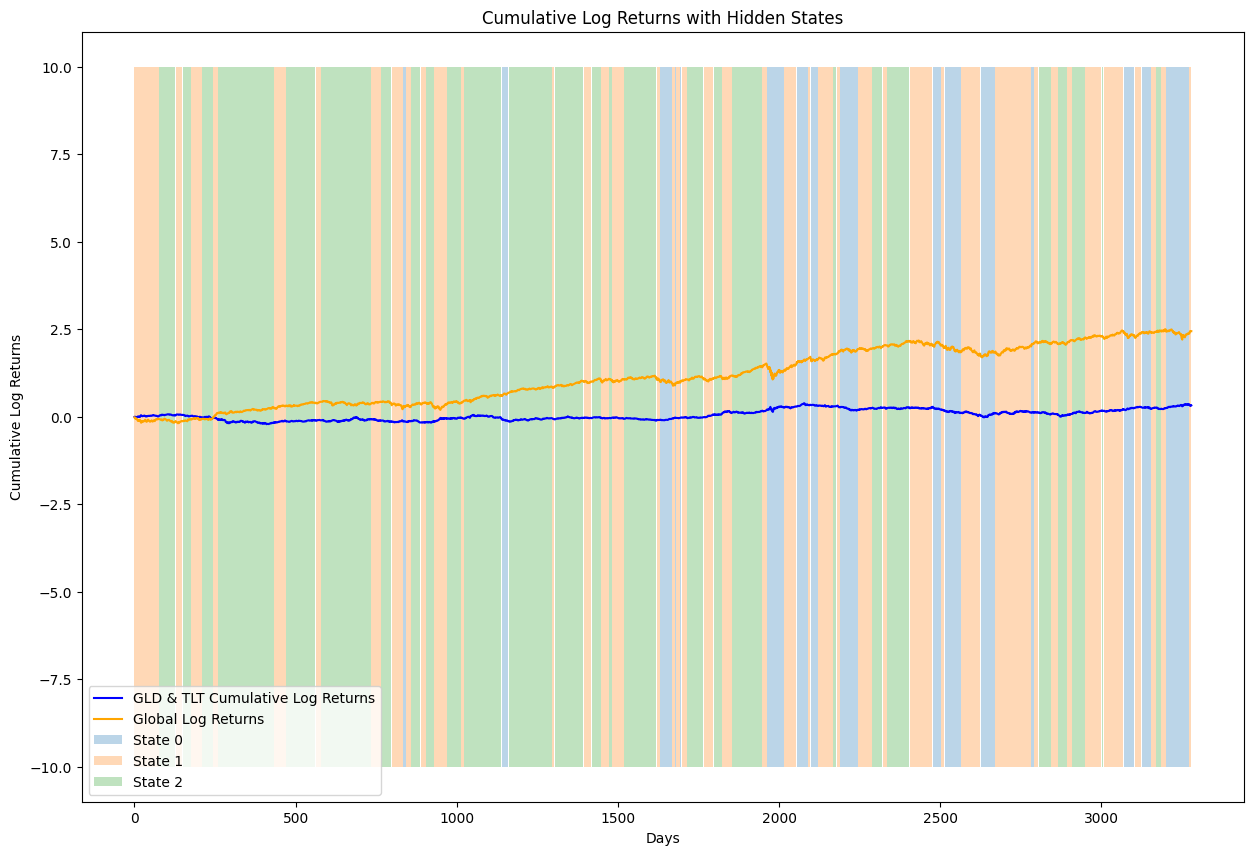

In [10]:
# On refait le calcul des états avec les deux tickers en plus, on prend comme paramètres :
# - ChipFearIndex
# - moyenne des actions hors GLD et TLT
# - moyenne de GLD et TLT
# - TNX_Diff

# calcul de la moyenne des actions hors GLD et TLT sans les 62 premiers jours car les indicateurs sont à partir de 62 jours de données
global_log_returns = data_log_returns.drop(columns=['Date', 'GLD', 'TLT', '^TNX', '^VIX'])[62:].mean(axis=1)

# calcul de la moyenne de GLD et TLT
gld_tlt_log_returns = data_log_returns[['GLD', 'TLT']][62:].mean(axis=1)

# création du DataFrame pour les 4 données d'entrée en resettant les index pour les aligner
hmm_data = pd.DataFrame({
    'ChipFearIndex': data_indicators['Chip_Fear_Index'].reset_index(drop=True),
    'GlobalLogReturns': global_log_returns.reset_index(drop=True),
    'GLD_TLT_LogReturns': gld_tlt_log_returns.reset_index(drop=True),
    'TNX_Diff': data_indicators['TNX_Diff'].reset_index(drop=True)
})

# on supprime la dernière année pour par la suite faire des tests
hmm_data_without_last_year = hmm_data[:-252]

print(hmm_data_without_last_year.head())
print(hmm_data_without_last_year.shape)

X_train = hmm_data_without_last_year[['ChipFearIndex', 'GlobalLogReturns', 'GLD_TLT_LogReturns', 'TNX_Diff']].values
# On standardise les données pour que le HMM puisse mieux les traiter
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# on utulise ici l'algorithme de Baum-Welch (Forward-Backward) pour estimer les paramètres du HMM, ce qui est plus adapté pour la classification non supervisée
model = hmm.GaussianHMM(n_components=3, covariance_type='full', n_iter=1000, random_state=42)
model.fit(X_train)

# on utilise ensuite Viterbi pour prédire les états cachés
hidden_states = model.predict(X_train)
print("Hidden states:", hidden_states)

# modifié pour unifier par rapport à avant état 0<=>1 et 2 reste 2
hidden_states = [1 if x == 0 else 0 if x == 1 else 2 for x in hidden_states]

# on ajoute les états cachés au DataFrame pour pouvoir les analyser
hmm_data_without_last_year['HiddenState'] = hidden_states

# on affiche la courbe "GLD et TLT" et la courbe desautres tickers en coloriant le fond en fonction de l'état caché pour visualiser les différences entre les états tout sur le même graphique en cummulant les log returns de GLD et TLT et la moyenne des autres tickers
plt.figure(figsize=(15, 10))
plt.plot(hmm_data_without_last_year['GLD_TLT_LogReturns'].cumsum(), label='GLD & TLT Cumulative Log Returns', color='blue')
plt.plot(hmm_data_without_last_year['GlobalLogReturns'].cumsum(), label='Global Log Returns', color='orange')
for state in np.unique(hidden_states):
    plt.fill_between(hmm_data_without_last_year.index, -10, 10, where=(hmm_data_without_last_year['HiddenState'] == state), alpha=0.3, label=f'State {state}')
plt.title('Cumulative Log Returns with Hidden States')
plt.xlabel('Days')
plt.ylabel('Cumulative Log Returns')
plt.legend()
plt.show()

In [11]:
profil = hmm_data_without_last_year.groupby('HiddenState').mean()
print("Profil des états cachés:")
print(profil)
print("Matrice de transition:")
print(model.transmat_)

print("\nMeans:")
print(model.means_)

Profil des états cachés:
             ChipFearIndex  GlobalLogReturns  GLD_TLT_LogReturns  TNX_Diff
HiddenState                                                               
0                 0.551925         -0.000605           -0.000107  0.001382
1                 0.376021          0.001263            0.000242  0.000645
2                 0.264965          0.000785            0.000055  0.000641
Matrice de transition:
[[9.61311821e-01 1.37516456e-02 2.49365337e-02]
 [3.30732014e-02 9.66926799e-01 2.00291910e-59]
 [1.86566294e-02 6.24350381e-04 9.80719020e-01]]

Means:
[[ 2.08842915e-01  3.98146895e-02  7.98731278e-03  2.46434483e-03]
 [ 1.69687074e+00 -9.72869326e-02 -6.44441711e-03  1.37888110e-03]
 [-7.39190974e-01  2.30201093e-03 -3.98773881e-03 -2.37645179e-03]]


In [12]:
print("\nCovariances:")
print(model.covars_)


Covariances:
[[[ 1.05619247e-01  2.31441207e-02  3.76587738e-03  9.13354932e-03]
  [ 2.31441207e-02  8.90819212e-01 -7.63533598e-02 -1.91633186e-02]
  [ 3.76587738e-03 -7.63533598e-02  9.41898014e-01  5.31738875e-02]
  [ 9.13354932e-03 -1.91633186e-02  5.31738875e-02  1.06041109e+00]]

 [[ 1.14130820e+00  1.60636229e-01  1.67024582e-01 -5.39299159e-02]
  [ 1.60636229e-01  2.89069182e+00  2.68245788e-02 -1.05912171e-01]
  [ 1.67024582e-01  2.68245788e-02  1.57906206e+00 -1.36607959e-01]
  [-5.39299159e-02 -1.05912171e-01 -1.36607959e-01  1.64915083e+00]]

 [[ 8.38488313e-02  1.89422650e-03  1.63360516e-03  6.54958664e-03]
  [ 1.89422650e-03  4.36516435e-01 -6.43091776e-02 -2.66170998e-02]
  [ 1.63360516e-03 -6.43091776e-02  8.47806385e-01  4.02770833e-02]
  [ 6.54958664e-03 -2.66170998e-02  4.02770833e-02  7.32303057e-01]]]


On test ce code en réalissant un Walk Forward Backtester avec Rééquilibrage

Après avoir créer le modèle qui nous parrait le mieux il est intéressant de le tester dans des conditions réels et de prendre ça en compte dès le début pour bien coder les fonctions par la suite. On veut donc tester sur la dernière année non apprise les états pris et investir grâce à cela. Puisque l'on veut tester plusieurs cas, on choisit d'ajouter un terme short_limit pour gérer le découvert autoriser en % (si 0 le découvert est inderdit)

In [13]:
import scipy.optimize as sco
def portfolio_performance(w, mean_returns, cov_matrix):
    returns = np.sum(mean_returns * w) * 252
    std = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w))) * np.sqrt(252)
    return returns, std

def negative_sharpe_ratio(w, mean_returns, cov_matrix, risk_free_rate=0.02):
    returns, std = portfolio_performance(w, mean_returns, cov_matrix)
    # Gérer le cas où std est très proche de 0 pour éviter la division par zéro
    if std == 0:
        return 0
    return -(returns - risk_free_rate) / std

def optimize_markowitz(mean_returns, cov_matrix, short_limit=0.0, max_weight=0.30):
    """
    Optimise le portefeuille pour maximiser le Sharpe Ratio.
    short_limit : -0.3 permet 30% de vente à découvert. 0.0 interdit la vente à découvert.
    """
    num_assets = len(mean_returns)
    args = (mean_returns, cov_matrix)
    
    # Contrainte : La somme de TOUS les poids (longs et shorts) doit faire 1 (100% d'exposition nette)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    
    # Bornes : min = short_limit, max = max_weight (ex: 30% max par actif pour forcer la diversification)
    bounds = tuple((short_limit, max_weight) for _ in range(num_assets))
    
    # Poids initiaux (Equally Weighted)
    initial_guess = num_assets * [1. / num_assets]
    
    result = sco.minimize(negative_sharpe_ratio, initial_guess, args=args,
                          method='SLSQP', bounds=bounds, constraints=constraints)
    
    # Nettoyage des poussières (ex: 1e-17 devient 0)
    return np.round(result.x, 4)

On code un autre algorithme de Risk Parity pour éviter la grande dépendance de Markowitz sur $\mu$

In [14]:
def risk_parity_objective(w, cov_matrix):
    # Calcul du risque total du portefeuille
    portfolio_risk = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))
    
    # Sécurité pour éviter la division par zéro
    if portfolio_risk == 0:
        return 1e9
        
    # Contribution marginale au risque (MRC)
    mrc = np.dot(cov_matrix, w) / portfolio_risk
    
    # Contribution au risque de chaque actif (RC = w * MRC)
    rc = w * mrc
    
    # Objectif : La cible de risque est égale pour tous (Risque total / Nombre d'actifs)
    target_rc = portfolio_risk / len(w)
    
    # On minimise la somme des erreurs au carré par rapport à cette cible
    # On ajoute une forte pénalité si les poids produisent un RC négatif (complexe mathématiquement)
    penalty = np.sum(np.maximum(0, -rc)) * 1000 
    
    return np.sum(np.square(rc - target_rc)) + penalty

def optimize_risk_parity(cov_matrix, short_limit=0.0, max_weight=0.30):
    """
    Optimise le portefeuille selon la Parité des Risques (Risk Parity).
    """
    num_assets = len(cov_matrix)
    args = (cov_matrix,)
    
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((short_limit, max_weight) for _ in range(num_assets))
    
    initial_guess = num_assets * [1. / num_assets]
    
    result = sco.minimize(risk_parity_objective, initial_guess, args=args,
                          method='SLSQP', bounds=bounds, constraints=constraints)
    
    return np.round(result.x, 4)

In [15]:
assets = ['USO', 'ASML', 'TSM', 'NVDA', 'AAPL', 'MSFT', 'GLD', 'TLT']
portfolio_returns = data_daily_returns[assets]
mean_returns = portfolio_returns.mean()
cov_matrix = portfolio_returns.cov()

print("--- 1. Markowitz Long-Only ---")
w1 = optimize_markowitz(mean_returns, cov_matrix, short_limit=0.0)
print(dict(zip(assets, w1)), f"(Sum: {np.sum(w1):.2f})")

print("\n--- 2. Markowitz Long/Short (-30%) ---")
w2 = optimize_markowitz(mean_returns, cov_matrix, short_limit=-0.3)
print(dict(zip(assets, w2)), f"(Sum: {np.sum(w2):.2f})")

print("\n--- 3. Risk Parity Long-Only ---")
w3 = optimize_risk_parity(cov_matrix, short_limit=0.0)
print(dict(zip(assets, w3)), f"(Sum: {np.sum(w3):.2f})")

print("\n--- 4. Risk Parity Long/Short (-30%) ---")
w4 = optimize_risk_parity(cov_matrix, short_limit=-0.3)
print(dict(zip(assets, w4)), f"(Sum: {np.sum(w4):.2f})")

--- 1. Markowitz Long-Only ---
{'USO': np.float64(0.0), 'ASML': np.float64(0.0), 'TSM': np.float64(0.1365), 'NVDA': np.float64(0.3), 'AAPL': np.float64(0.1598), 'MSFT': np.float64(0.054), 'GLD': np.float64(0.2812), 'TLT': np.float64(0.0686)} (Sum: 1.00)

--- 2. Markowitz Long/Short (-30%) ---
{'USO': np.float64(-0.1005), 'ASML': np.float64(-0.0172), 'TSM': np.float64(0.1689), 'NVDA': np.float64(0.3), 'AAPL': np.float64(0.1882), 'MSFT': np.float64(0.0899), 'GLD': np.float64(0.3), 'TLT': np.float64(0.0707)} (Sum: 1.00)

--- 3. Risk Parity Long-Only ---
{'USO': np.float64(0.0), 'ASML': np.float64(0.1194), 'TSM': np.float64(0.0803), 'NVDA': np.float64(0.0771), 'AAPL': np.float64(0.0581), 'MSFT': np.float64(0.0652), 'GLD': np.float64(0.3), 'TLT': np.float64(0.3)} (Sum: 1.00)

--- 4. Risk Parity Long/Short (-30%) ---
{'USO': np.float64(-0.1567), 'ASML': np.float64(0.1508), 'TSM': np.float64(0.1116), 'NVDA': np.float64(0.1084), 'AAPL': np.float64(0.0894), 'MSFT': np.float64(0.0965), 'GLD': np

On génère le walk forward backtester avec rééquilibrage

In [16]:
def run_walk_forward_backtest(df_test_returns, X_full, train_size, hmm_model, 
                              historical_means, historical_covs, assets, k_days=21):
    """
    Backtester institutionnel avec rééquilibrage périodique et HMM Forward.
    
    df_test_returns: Rendements simples quotidiens des 252 derniers jours.
    X_full: Le tenseur HMM complet (Train + Test) standardisé.
    train_size: Index où se termine l'entraînement (ex: 3435 - 252).
    historical_means / historical_covs: Dictionnaires des matrices par régime (0, 1, 2) calculés sur le Train.
    k_days: Fréquence de rééquilibrage (en jours).
    """
    
    # Capital initial
    initial_capital = 10000.0
    
    # Historique de la valeur des 4 portefeuilles
    portfolios = {
        'Markowitz_LongOnly': {'value': initial_capital, 'weights': None, 'history': []},
        'Markowitz_LongShort': {'value': initial_capital, 'weights': None, 'history': []},
        'RiskParity_LongOnly': {'value': initial_capital, 'weights': None, 'history': []},
        'RiskParity_LongShort': {'value': initial_capital, 'weights': None, 'history': []}
    }
    
    predicted_states_history = []
    
    num_test_days = len(df_test_returns)
    print(f"Début du Backtest sur {num_test_days} jours. Rééquilibrage tous les {k_days} jours.")
    
    for t in range(num_test_days):
        # 1. PRÉDICTION TEMPS RÉEL (Algorithme Forward)
        # On donne au HMM les données depuis le tout début jusqu'à aujourd'hui (Zéro futur)
        X_visible = X_full[: train_size + t + 1]
        
        # predict_proba renvoie les probabilités des 3 états pour chaque jour. On prend le dernier jour [-1]
        # et on cherche l'index de la probabilité maximale (argmax)
        current_state = np.argmax(hmm_model.predict_proba(X_visible)[-1])
        predicted_states_history.append(current_state)
        
        # 2. RÉÉQUILIBRAGE (Seulement le jour 0 et tous les k jours)
        if t % k_days == 0:
            # On récupère les matrices historiques correspondant à l'état prédit
            mean_ret = historical_means[current_state]
            cov_mat = historical_covs[current_state]
            
            # Calcul des nouveaux poids optimaux
            portfolios['Markowitz_LongOnly']['weights'] = optimize_markowitz(mean_ret, cov_mat, short_limit=0.0)
            portfolios['Markowitz_LongShort']['weights'] = optimize_markowitz(mean_ret, cov_mat, short_limit=-0.3)
            portfolios['RiskParity_LongOnly']['weights'] = optimize_risk_parity(cov_mat, short_limit=0.0)
            portfolios['RiskParity_LongShort']['weights'] = optimize_risk_parity(cov_mat, short_limit=-0.3)
        
        # 3. MISE À JOUR QUOTIDIENNE DES PORTEFEUILLES (PnL)
        # On récupère les rendements réels des actifs pour ce jour t
        daily_returns = df_test_returns.iloc[t][assets].values
        
        for name, p in portfolios.items():
            # Le rendement du portefeuille = Produit scalaire des poids par les rendements du jour
            # (Note : Si on short un actif en baisse, le produit Poids Négatif * Rendement Négatif donne un PnL Positif !)
            port_daily_return = np.sum(p['weights'] * daily_returns)
            
            # Mise à jour de la valeur
            p['value'] = p['value'] * (1 + port_daily_return)
            p['history'].append(p['value'])
            
            # Mise à jour mathématique de la dérive des poids
            # Si NVDA monte de 10%, son poids dans le portefeuille grandit mécaniquement
            drifted_weights = p['weights'] * (1 + daily_returns)
            p['weights'] = drifted_weights / np.sum(drifted_weights)
            
    # Création du DataFrame final de reporting
    report_df = pd.DataFrame(index=df_test_returns.index)
    report_df['Predicted_Regime'] = predicted_states_history
    for name in portfolios.keys():
        report_df[name] = portfolios[name]['history']
        
    return report_df

On test cela

Début du Backtest sur 252 jours. Rééquilibrage tous les 21 jours.


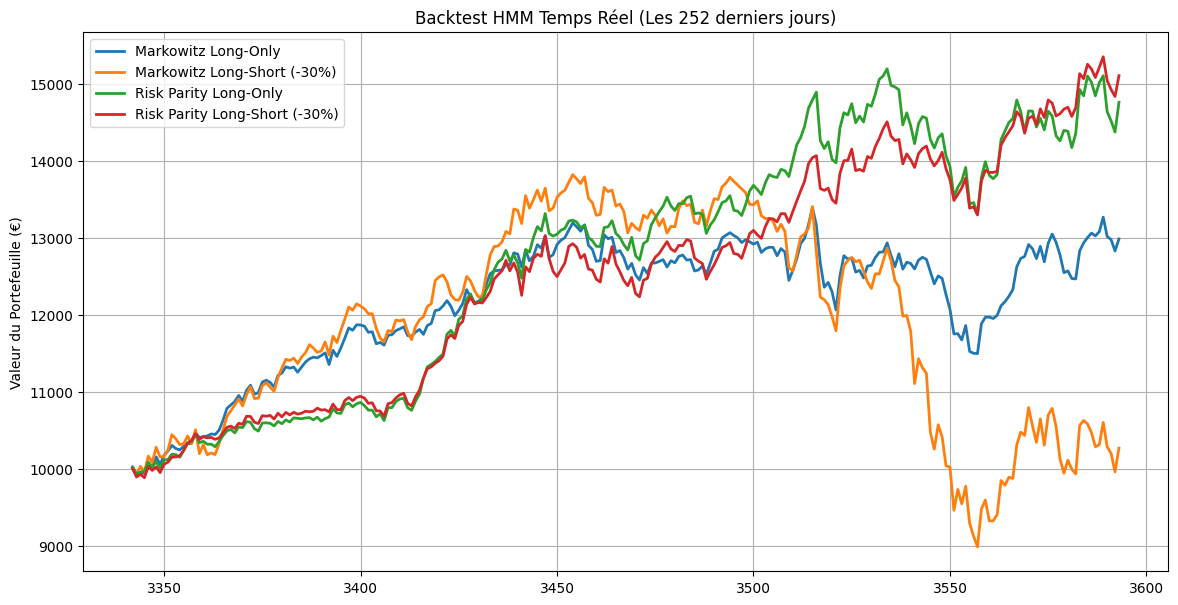

Performance Markowitz_LongOnly : 29.91%
Performance Markowitz_LongShort : 2.71%
Performance RiskParity_LongOnly : 47.68%
Performance RiskParity_LongShort : 51.14%


In [20]:
# --- PRÉPARATION DES DONNÉES ---
# Tes 8 actifs
assets_list = ['USO', 'ASML', 'TSM', 'NVDA', 'AAPL', 'MSFT', 'GLD', 'TLT']

# Taille de l'entrainement
train_size = len(hmm_data) - 252 

# Rendements simples pour la dernière année
# Assure-toi que data_daily_returns contient bien les rendements SIMPLES
df_test_returns = data_daily_returns[assets_list].tail(252)

# Matrices conditionnelles (Calculées sur le Train Set)
# Je simule ici ce que tu dois calculer avant avec un groupby sur l'état Viterbi du Train set
df_train_returns = data_daily_returns[assets_list].iloc[62 : -252].reset_index(drop=True)
df_train_returns['HiddenState'] = hmm_data_without_last_year['HiddenState'].values

historical_means_dict = {
    state : df_train_returns[df_train_returns['HiddenState'] == state][assets_list].mean().values
        for state in [0, 1, 2]
}
historical_cov_dict = {
    state : df_train_returns[df_train_returns['HiddenState'] == state][assets_list].cov().values
        for state in [0, 1, 2]
}

# --- LANCEMENT DE LA SIMULATION ---
X_full = scaler.transform(hmm_data[['ChipFearIndex', 'GlobalLogReturns', 'GLD_TLT_LogReturns', 'TNX_Diff']].values)
# X_train_full doit être ton tenseur HMM entier (les 3435 + 252 jours) standardisé !
backtest_results = run_walk_forward_backtest(
    df_test_returns=df_test_returns,
    X_full=X_full, 
    train_size=train_size,
    hmm_model=model, # Ton HMM entraîné
    historical_means=historical_means_dict,
    historical_covs=historical_cov_dict,
    assets=assets_list,
    k_days=21 # Rééquilibrage mensuel
)

# --- VISUALISATION DES RÉSULTATS ---
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(backtest_results['Markowitz_LongOnly'], label='Markowitz Long-Only', linewidth=2)
plt.plot(backtest_results['Markowitz_LongShort'], label='Markowitz Long-Short (-30%)', linewidth=2)
plt.plot(backtest_results['RiskParity_LongOnly'], label='Risk Parity Long-Only', linewidth=2)
plt.plot(backtest_results['RiskParity_LongShort'], label='Risk Parity Long-Short (-30%)', linewidth=2)

plt.title('Backtest HMM Temps Réel (Les 252 derniers jours)')
plt.ylabel('Valeur du Portefeuille (€)')
plt.legend()
plt.grid(True)
plt.show()

# Calcul de la performance finale
for col in backtest_results.columns[1:]:
    perf = (backtest_results[col].iloc[-1] / 10000.0 - 1) * 100
    print(f"Performance {col} : {perf:.2f}%")

On regarde ce qu'à fait l'algorithme

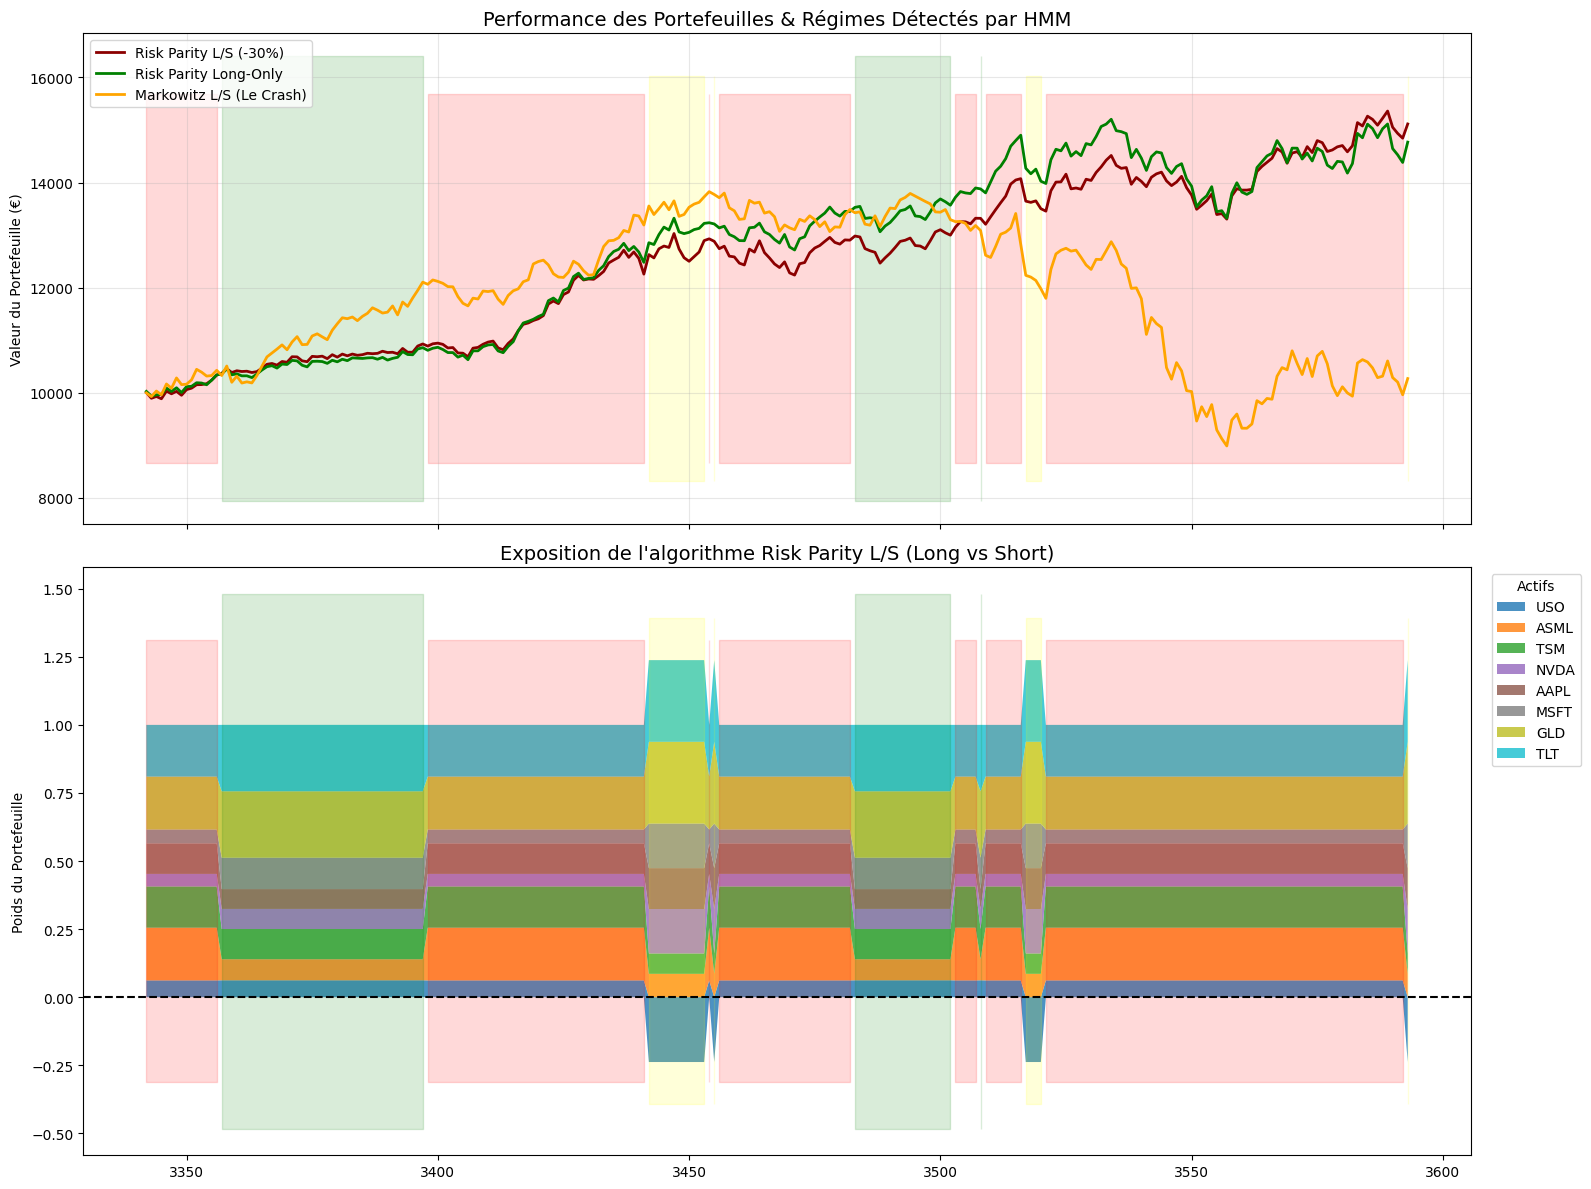


--- ALLOCATIONS CIBLES (RISK PARITY L/S) PAR ÉTAT CACHÉ (%) ---
             USO  ASML   TSM  NVDA  AAPL  MSFT   GLD   TLT
État HMM 0   6.2  19.4  15.2   4.6  11.2   5.1  19.4  19.0
État HMM 1 -23.8   8.6   7.5  16.3  15.0  16.4  30.0  30.0
État HMM 2   6.2   7.7  11.1   7.4   7.3  11.5  24.4  24.4


In [21]:
# 1. Recalculer les poids cibles du Risk Parity L/S pour les 3 états
target_weights = {}
for state in [0, 1, 2]:
    # On recalcule les poids exacts que l'algo a pris pour l'état donné
    target_weights[state] = optimize_risk_parity(historical_cov_dict[state], short_limit=-0.3)

# 2. Créer l'historique des poids sur les 252 jours
weights_history = []
for regime in backtest_results['Predicted_Regime']:
    weights_history.append(target_weights[regime])

df_weights = pd.DataFrame(weights_history, index=backtest_results.index, columns=assets_list)

# 3. CRÉATION DU GRAPHIQUE DOUBLE
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [1, 1.2]}, sharex=True)

# Couleurs pour les régimes (à ajuster selon tes observations de l'état 0, 1, 2)
# Ex: 0 = Crise (Rouge), 1 = Transition (Jaune), 2 = Croissance (Vert)
state_colors = {0: 'red', 1: 'yellow', 2: 'green'}

# --- AXE 1 : LA PERFORMANCE & RÉGIMES ---
ax1.plot(backtest_results.index, backtest_results['RiskParity_LongShort'], label='Risk Parity L/S (-30%)', color='darkred', linewidth=2)
ax1.plot(backtest_results.index, backtest_results['RiskParity_LongOnly'], label='Risk Parity Long-Only', color='green', linewidth=2)
ax1.plot(backtest_results.index, backtest_results['Markowitz_LongShort'], label='Markowitz L/S (Le Crash)', color='orange', linewidth=2)

ax1.set_title('Performance des Portefeuilles & Régimes Détectés par HMM', fontsize=14)
ax1.set_ylabel('Valeur du Portefeuille (€)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Colorier le fond selon les régimes
for state in [0, 1, 2]:
    ax1.fill_between(backtest_results.index, ax1.get_ylim()[0], ax1.get_ylim()[1],
                     where=(backtest_results['Predicted_Regime'] == state),
                     color=state_colors[state], alpha=0.15)

# --- AXE 2 : L'ALLOCATION LONG/SHORT ---
# Séparer les poids positifs (Long) et négatifs (Short)
df_pos = df_weights[df_weights > 0].fillna(0)
df_neg = df_weights[df_weights < 0].fillna(0)

# Couleurs pour chaque actif
colors_assets = plt.cm.tab10(np.linspace(0, 1, len(assets_list)))

# Aire empilée pour les positions Long (>0)
ax2.stackplot(df_weights.index, df_pos.T, labels=df_pos.columns, colors=colors_assets, alpha=0.8)
# Aire empilée pour les positions Short (<0)
ax2.stackplot(df_weights.index, df_neg.T, colors=colors_assets, alpha=0.8)

ax2.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax2.set_title("Exposition de l'algorithme Risk Parity L/S (Long vs Short)", fontsize=14)
ax2.set_ylabel('Poids du Portefeuille')
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1), title="Actifs") # Légende à l'extérieur

# Colorier le fond de l'axe 2 aussi
for state in [0, 1, 2]:
    ax2.fill_between(backtest_results.index, ax2.get_ylim()[0], ax2.get_ylim()[1],
                     where=(backtest_results['Predicted_Regime'] == state),
                     color=state_colors[state], alpha=0.15)

plt.tight_layout()
plt.show()

# --- PRINT POUR L'ANALYSE ---
print("\n--- ALLOCATIONS CIBLES (RISK PARITY L/S) PAR ÉTAT CACHÉ (%) ---")
df_targets = pd.DataFrame(target_weights, index=assets_list).T
df_targets.index = [f"État HMM {i}" for i in df_targets.index]
print((df_targets * 100).round(1))

C'est très bon mais malheuresement :
- Le Bid-Ask Spread & Slippage :
    -   Dans le backtest, on achète au prix exact de "Clôture" (Close). Dans la réalité, le prix de clôture est une moyenne ou le dernier prix échangé. Quand on passe son ordre de marché, on achète au prix vendeur (Ask) et vend au prix acheteur (Bid). On perd un petit pourcentage à chaque transaction. Face à des HFT (High-Frequency Traders), on subit donc un léger slippage (glissement de prix)
- Les frais de courtage (Commissions) :
    - Bien que faibles aujourd'hui avec certaines banques, ils ne sont pas nuls. L'avantage du modèle est que l'on ne rééquilibres que tous les 21 jours. Les frais seront donc minimes comparés à un bot de Day Trading
- Le coût du Short (Vente à découvert) :
    - Le backtest suppose que l'on peux "shorter" jusqu'à 30% d'un actif gratuitement. Dans la vraie vie, on dois emprunter l'action à son courtier, ce qui génère des frais d'emprunt (Borrow Fees) journaliers. Shorter des actions très demandées (comme NVDA) coûte cher en taux d'intérêt marginaux
- Le problème du Timing (Look-ahead constraint) :
    - Le HMM a besoin de la clôture du jour t pour calculer l'état. Si l'on calcule l'état à 22h00 après la fermeture de Wall Street, on doit passer ses ordres le lendemain à 15h30 (Heure de Paris) à l'Ouverture (Open). Entre le Close de la veille et l'Open du lendemain, il y a un "Gap" de prix (les marchés bougent la nuit)